# Distributional scalar curvature
After the [distributional Gauss curvature](06_distributional_gauss_curvature.ipynb), we consider the distributional scalar curvature for arbitrarily dimensional Riemannian manifolds in this notebook. In two dimensions, the scalar curvature and the Gauss curvature coincide up to a factor $2$. We will see that the angle defect directly extends to a higher dimension and that the geodesic curvature becomes the mean curvature. Further, the integral representation of the distributional scalar curvature splits into two parts, where the second one is zero in the two-dimensional case and can be identified with the distributional Einstein tensor discussed in the [next notebook](10_distributional_einstein_tensor.ipynb). For a detailed derivation and analysis, we refer to [Gawlik, Neunteufel. *Finite element approximation of scalar curvature in arbitrary dimension*, *Math. Comp.* (2024).](https://doi.org/10.1090/mcom/4038).




## Scalar curvature as a nonlinear distribution
The scalar curvature $S$ is the double contraction of the Riemann curvature tensor $\mathfrak{R}$ or equivalently the contraction of the Ricci curvature tensor $\mathrm{Ric}$

$$
\begin{align*}
S = g^{ij}g^{kl}\mathfrak{R}_{iklj}=g^{ij}\mathrm{Ric}_{ij}.
\end{align*}
$$

With the same arguments as for the Gauss curvature, the scalar curvature is a nonlinear (quasi-linear) second-order differential operator of the metric. 

The distributional (densitized) scalar curvature acting on a sufficiently smooth scalar-valued test function $\varphi$ is defined as

$$
\begin{align*}
\widetilde{S\omega}(\varphi) :=\sum_{T\in\mathcal{T}}\int_TS|_T\,\varphi\,\omega_T+2\sum_{F\in\mathcal{F}}\int_F[\![H]\!]\,\varphi\,\omega_F+2\sum_{E\in\mathcal{E}}\int_E\Theta_E\,\varphi\,\omega_E,
\end{align*}
$$

where $\omega_T$, $\omega_F$, and $\omega_E$ are the respective volume forms on elements $T$, co-dimension 1 facets $F$ and co-dimension two boundaries $E$ (vertices in 2D, edges in 3D, etc.). $H$ denotes the mean curvature defined as the trace of the second fundamental form $I\!I$

$$
\begin{align*}
H:= \mathrm{tr}_{g_F}(I\!I)= g_F^{ij}I\!I_{ij},\qquad I\!I(X,Y) = g(\nabla_Xn,Y)=-g(\nabla_XY,n),\quad X,Y\in \mathfrak{X}(F),
\end{align*}
$$

where $n$ is the outward unit normal of each element at the facet and $\Theta_E$ is the angle defect. In the numerical example, normal_sign=-1 supplies the inward normal $\nu=-n$ to mf.SFF. Its convention $g(\nabla_XY,\nu)$ gives the same $I\!I(X,Y)$ as above. Note that the angle defect directly extends from 2D to any dimension, as we measure the angle in the two-dimensional plane perpendicular to the co-dimension 2 boundary.

Although there is no Gauss-Bonnet theorem in arbitrary dimension, we can heuristically motivate the jump of the mean curvature as the appropriate facet term. At a point of a facet $p\in F$, the scalar curvature can be expressed as the sum of sectional curvatures of $N(N-1)/2$ tangent planes, $N$ denoting the dimension, that are pairwise $g$-perpendicular at $p$. $(N-1)(N-2)/2$ of those planes are tangent to $F$ and $N-1$ ones are $g$-perpendicular to $F$ at $p$. Because of the tangential-tangential continuity of the Regge metric, the sectional curvature of the planes tangent to $F$ are non-singular and do not yield a contribution to the facet term. The other $N-1$ planes, however, have jumping curvature. On these two-dimensional planes, we can apply the Gauss-Bonnet theorem. Summing up those ``geodesic curvature jumps'' yields the jump of the mean curvature of $F$.


## Integral representation and convergence

Taking the variation of the densitized distributional scalar curvature in the metric in direction $\sigma$ yields

$$
\begin{align*}
D_g\widetilde{S\omega}(v)[\sigma] = b_h(g;\sigma,v)-a_h(g;\sigma,v)
\end{align*}
$$

with

$$
\begin{align*}
b_h(g;\sigma,v)&= \sum_T\int_T\langle\mathbb{S}\sigma,\nabla^2v\rangle\,\omega_T-\sum_{F}\int_F\mathbb{S}\sigma(n,n)[\![\nabla_n v]\!]_F\,\omega_F,\\
a_h(g;\sigma,v)&= \sum_T\int_T\langle G,\sigma\rangle\,v\,\omega_T+\sum_F\int_F\langle [\![\bar{I\!I}]\!]_F,\sigma|_F\rangle\,v\omega_F-\sum_{E}\int_E\langle\Theta_Eg|_E,\sigma|_E\rangle\,v\,\omega_E.
\end{align*}
$$

Here, all differential operators are covariant with respect to the metric $g$. $\bar{I\!I}=I\!I-H\,g|_F$ denotes the trace-reversed second fundamental form and $G=\mathrm{Ric}-1/2S\,g$ is the Einstein tensor. Note that in two dimensions, $a(g;\sigma,v)$ becomes identically zero, and $b_h(g;\sigma,v)$ coincides with the expression of the integral representation of the distributional Gauss curvature. As we will discuss in the [following notebook](10_distributional_einstein_tensor.ipynb), $a_h(g;\sigma,v)$ can be interpreted as the distributional Einstein tensor when we set $v=1$. $b_h(g;\sigma,v)$ can also be interpreted as extending the (covariant) Hellan-Herrmann-Johnson method to arbitrary dimensions. Its numerical analysis follows the same lines as for the Gauss curvature. In three and higher dimensions, however, the bilinear form $a_h(g;\sigma,v)$ needs to be estimated too. 

We obtain the following convergence rates in the $H^{-2}$ norm for $k\ge 0$ and $g_h\in \mathrm{Reg}^k$

$$
\begin{align*}
\|\widetilde{S\omega}(g_h)-(S\omega)(g)\|_{H^{-2}}\le C\begin{cases}
h^{k+1}, & N=2\\
h^{\min\{k+1,2k\}}, &N \ge 3
\end{cases}.
\end{align*}
$$

We proved that in 2D, the angle defect for approximating the scalar (and therefore Gauss) curvature always converges in the $H^{-2}$ norm. Before, only convergence in the sense of measures was known. We cannot expect convergence in the lowest-order case, $k=0$, of a piecewise constant Regge metric for three or higher dimensions. When going to linear order, the convergence rate jumps to be quadratic. Then, the dependency on the polynomial approximation order relates to the convergence rate as expected. The co-dimension 2 term of $a_h(g;\sigma,v)$ turns out to be the issue for not obtaining convergence in the lowest-order case. Unfortunately, numerical investigations show that this estimate is sharp. Nevertheless, in several examples, we still observed linear convergence as the absolute error of this term seems to be small, and the error of the other terms dominates such that the stagnation of error is hard to spot. 


## Numerical example
In the following example, we compute the distributional scalar curvature $\widetilde{S\omega}$ on a sequence of meshes for a three-dimensional Riemannian manifold and compute the $H^{-2}$ error.

In [1]:
from ngsolve.meshes import MakeStructured3DMesh
from ngsolve import *
from ngsolve.webgui import Draw
import random as random
from ngsolve.krylovspace import CGSolver
import numpy as np
import ngsdiffgeo as dg


def mapping(x, y, z):
    return (2 * x - 1, 2 * y - 1, 2 * z - 1)


mesh = MakeStructured3DMesh(False, nx=4, ny=4, nz=4, mapping=mapping)

# Define an embedded "3D-surface" in 4D via a graph function
peak = (
    0.5 * x**2 - 1 / 12 * x**4 + 0.5 * y**2 - 1 / 12 * y**4 + 0.5 * z**2 - 1 / 12 * z**4
)

# compute the exact induced metric tensor G
F = CF(
    (1, 0, 0, 0, 1, 0, 0, 0, 1, peak.Diff(x), peak.Diff(y), peak.Diff(z)), dims=(4, 3)
)
G_ex = F.trans * F


# exact scalar curvature
def q(x):
    return x**2 * (x**2 - 3) ** 2


# exact scalar curvature
S_ex = (
    18
    * (
        (1 - x**2) * (1 - y**2) * (9 + q(z))
        + (1 - y**2) * (1 - z**2) * (9 + q(x))
        + (1 - z**2) * (1 - x**2) * (9 + q(y))
    )
) / ((9 + q(x) + q(y) + q(z)) ** 2)

Draw(S_ex, mesh);

<netgen.webgui.WebGuiWidget>: Run `pip install anywidget` to enable WebGuiWidget in Jupyter

We compute the $H^{-2}$-norm of the error $\|\widetilde{S\omega}-S\omega\|_{H^{-2}}$ by solving the following fourth-order problem $\mathrm{div}(\mathrm{div}(\nabla^2 u))= \widetilde{S\omega}-S\omega$. Then $\|u\|_{H^2}\approx \|\widetilde{S\omega}-S\omega\|_{H^{-2}}$. We use the Euclidean Hellan-Herrmann-Johnson (HHJ) method to solve the fourth-order problem as a mixed saddle point problem. Therein, $\sigma=\nabla^2u$ is introduced as an additional unknown. We use hybridization techniques to regain a minimization problem. We use a BDDC preconditioner in combination with static condensation and a CGSolver to solve the problem iteratively. To mitigate approximation errors that spoil the convergence, we use two polynomial degrees more than for $g_h$ to compute $u_h$. 

In [2]:
# compute H^-2 error via HHJ method
def ComputeHm2Norm(func_vol, func_bnd, func_bbnd, mesh, order):
    fesH = H1(mesh, order=order, dirichlet=".*")
    fesS = Discontinuous(HDivDiv(mesh, order=order - 1))
    fesHB = NormalFacetFESpace(mesh, order=order - 1, dirichlet=".*")
    fes = fesH * fesS * fesHB
    (u, sigma, uh), (v, tau, vh) = fes.TnT()

    n = specialcf.normal(mesh.dim)

    a = BilinearForm(fes, symmetric=True, symmetric_storage=True, condense=True)
    a += (
        InnerProduct(sigma, tau)
        - InnerProduct(tau, u.Operator("hesse"))
        - InnerProduct(sigma, v.Operator("hesse"))
    ) * dx
    a += ((Grad(u) - uh) * n * tau[n, n] + (Grad(v) - vh) * n * sigma[n, n]) * dx(
        element_boundary=True
    )

    f = LinearForm(fes)
    f += (
        func_vol * v * dx
        + func_bnd * v * dx(element_boundary=True)
        + func_bbnd * v * dx(element_vb=BBND)
    )
    f.Assemble()

    apre = Preconditioner(a, "bddc")
    a.Assemble()
    invS = CGSolver(a.mat, apre.mat, printrates="\r", maxiter=400)
    ext = IdentityMatrix() + a.harmonic_extension
    inv = a.inner_solve + ext @ invS @ ext.T

    gf_error_lift = GridFunction(fes)
    gf_error_lift.vec.data = inv * f.vec

    gf_u, gf_sigma, _ = gf_error_lift.components
    # "sigma = hesse u"
    err = sqrt(
        Integrate(gf_u**2 + Grad(gf_u) ** 2 + InnerProduct(gf_sigma, gf_sigma), mesh)
    )
    return err

The following function computes the $H^2$-error of the distributional scalar curvature for a given metric and polynomial order. 

In [3]:
# main function to compute the scalar curvature
def ComputeScalarCurvature(mesh, G, order):
    fesCC = HCurlCurl(mesh, order=order)
    gfG = GridFunction(fesCC)
    gfG.Set(G)
    mf = dg.RiemannianManifold(gfG, normal_sign=-1)

    # Element-local densities of the distributional scalar curvature.
    func_bbnd = 2 * mf.AngleDefect * mf.VolumeForm(BBND)
    func_bnd = 2 * mf.MeanCurvature * mf.VolumeForm(BND)
    func_vol = mf.Scalar * mf.VolumeForm(VOL) - S_ex * sqrt(Det(G))

    err_hm2 = ComputeHm2Norm(func_vol, func_bnd, func_bbnd, mesh, order=order + 2)
    return (err_hm2, fesCC.ndof)

To avoid possible super-convergence due to symmetries in the mesh, we perturb the internal vertices by a random noise.

In [4]:
# compute the diameter of the mesh as maximal mesh size h
def CompDiam(mesh):
    lengths = np.zeros(mesh.nedge)
    for edge in mesh.edges:
        pnts = []
        for vert in edge.vertices:
            pnt = mesh[vert].point
            pnts.append((pnt[0], pnt[1], pnt[2]))
        lengths[edge.nr] = sqrt(
            (pnts[0][0] - pnts[1][0]) ** 2
            + (pnts[0][1] - pnts[1][1]) ** 2
            + (pnts[0][2] - pnts[1][2]) ** 2
        )

    print(f"max = {max(lengths)}, min = {min(lengths)}, ne = {mesh.ne}")
    return max(lengths)


# generate and randomly perturb it, check if the resulting mesh is valid
def GenerateRandomMesh(k, par):
    for i in range(20):
        mesh = MakeStructured3DMesh(False, nx=2**k, ny=2**k, nz=2**k, mapping=mapping)
        maxh = CompDiam(mesh)
        for pnts in mesh.ngmesh.Points():
            px, py, pz = pnts[0], pnts[1], pnts[2]
            if (
                abs(px + 1) > 1e-8
                and abs(px - 1) > 1e-8
                and abs(py + 1) > 1e-8
                and abs(py - 1) > 1e-8
                and abs(pz + 1) > 1e-8
                and abs(pz - 1) > 1e-8
            ):
                px += random.uniform(-maxh / 2**par / sqrt(2), maxh / 2**par / sqrt(2))
                py += random.uniform(-maxh / 2**par / sqrt(2), maxh / 2**par / sqrt(2))
                pz += random.uniform(-maxh / 2**par / sqrt(2), maxh / 2**par / sqrt(2))
            pnts[0] = px
            pnts[1] = py
            pnts[2] = pz
        F = specialcf.JacobianMatrix(3)
        # check if the mesh is valid
        if Integrate(IfPos(Det(F), 0, -1), mesh) >= 0:
            break
    else:
        raise Exception("Could not generate a valid mesh")

    return mesh

Compute the scalar curvature approximation on a sequence of meshes. You can play around with the polynomial order. The $H^{-2}$ error and the number of degrees of freedom are stored.

In [5]:
err_hm2 = []
ndof = []

# order of metric approximation >= 0
order = 1

with TaskManager():
    for i in range(0, 4):
        mesh = GenerateRandomMesh(k=i, par=3)
        errm2, dof = ComputeScalarCurvature(mesh, G=G_ex, order=order)
        err_hm2.append(errm2)
        ndof.append(dof)

max = 3.4641016151377544, min = 2.0, ne = 6
CG converged in 3 iterations to residual 1.1911238862277332e-14
max = 1.7320508075688772, min = 1.0, ne = 48
CG converged in 36 iterations to residual 7.726907543945067e-14
max = 0.8660254037844386, min = 0.5, ne = 384


CG converged in 53 iterations to residual 2.5926915033523212e-14
max = 0.4330127018922193, min = 0.25, ne = 3072


CG converged in 60 iterations to residual 1.0620998614469438e-14


Plot the results together with reference lines for linear, quadratic, and cubic convergence order.

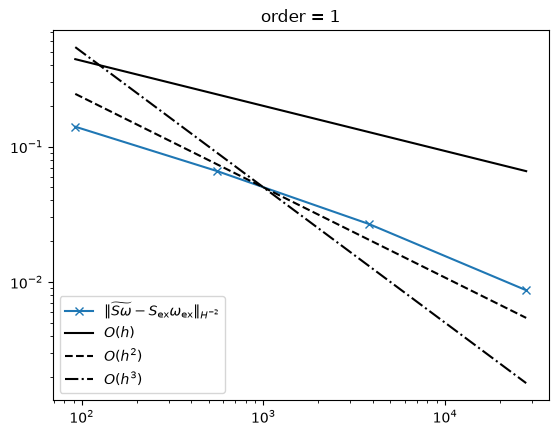

In [6]:
import matplotlib.pyplot as plt

plt.plot(
    ndof,
    err_hm2,
    "-x",
    label=r"$\|\widetilde{S\omega}-S_{\mathrm{ex}}\omega_{\mathrm{ex}}\|_{H^{-2}}$",
)
plt.plot(ndof, [2 * dof ** (-1 / 3) for dof in ndof], "-", color="k", label="$O(h)$")
plt.plot(ndof, [5 * dof ** (-2 / 3) for dof in ndof], "--", color="k", label="$O(h^2)$")
plt.plot(
    ndof, [50 * dof ** (-3 / 3) for dof in ndof], "-.", color="k", label="$O(h^3)$"
)


plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.title(f"order = {order}")
plt.show()